# Encapsulator demo

Uses the `MovieDatabase` class from `movie_database.py`. The notebook never writes connection code: it creates the database object once and asks it for tables.


In [1]:
import matplotlib.pyplot as plt   # for the charts
from encapsulator import MovieDatabase

db = MovieDatabase()   # a pop-up at the top of VS Code asks for the PostgreSQL password

/Users/huyennguyen/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/huyennguyen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## H1: Budget
Average budget and average domestic, international and worldwide box office for three budget groups.

In [2]:
# runs the H1 query and gives back a DataFrame
h1 = db.budget_vs_box_office() 
h1

,budget_group,films,avg_budget,avg_domestic_box_office,avg_international_box_office,avg_worldwide_box_office
0,under 20M,2827,8151241.0,14955012.0,14053085.0,29008097.0
1,20M - 100M,3126,43867492.0,54119020.0,59510751.0,113629770.0
2,100M and more,747,154886345.0,177652044.0,319094943.0,496746987.0


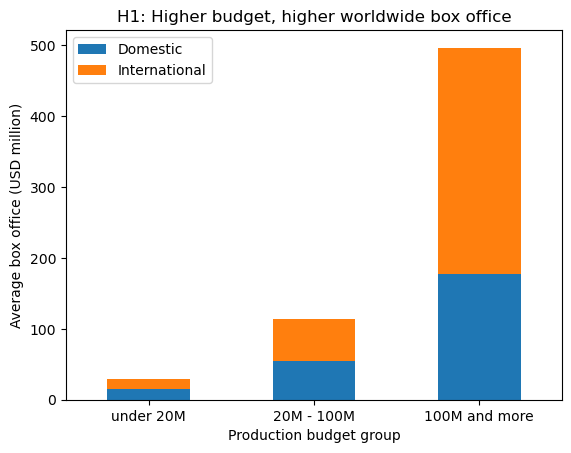

In [3]:
# H1 chart: average box office per budget group, split into domestic and international.
# The full bar height is the average worldwide box office.
chart = h1.set_index("budget_group")[["avg_domestic_box_office", "avg_international_box_office"]] / 1_000_000
ax = chart.plot(kind="bar", stacked=True, rot=0, title="H1: Higher budget, higher worldwide box office")
ax.set_xlabel("Production budget group")
ax.set_ylabel("Average box office (USD million)")
ax.legend(["Domestic", "International"])
plt.show()

Box office rises steeply with budget. Average worldwide gross is $29M for films under $20M, $114M for $20M to $100M, and $497M for $100M and more.
Returns are roughly 3x at every level. The ratio of average worldwide gross to average budget is about 3.6x, 2.6x and 3.2x. Higher budgets mean bigger grosses, but the return on each dollar doesn't improve. The mid tier is actually the weakest.
The international share grows with budget. International is 48% of worldwide gross for the low tier, 52% for the mid tier and 64% for the top tier. Big-budget films depend on overseas markets. Low-budget films are slightly more domestic (about $15.0M domestic vs $14.1M international).
Caveat: these are averages, which blockbusters pull up. The 747 films in the top tier are few, so a handful of hits can drive that bar.

## H2: Theatre count
Median worldwide box office for four groups of opening theatre counts.

In [4]:
# runs the H2 query and gives back a DataFrame
h2 = db.theatres_vs_box_office()   
h2

,opening_theatres,films,median_worldwide_box_office
0,under 100,5196,2145764.0
1,100 - 599,647,4495262.0
2,600 - 1999,775,16628751.0
3,2000 and more,3938,95104304.0


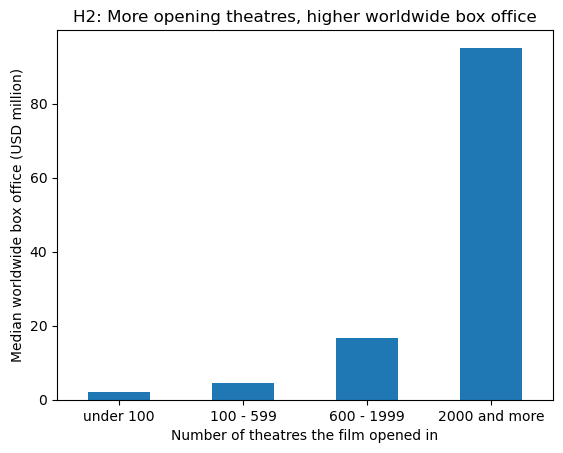

In [5]:
# H2 chart: median worldwide box office per group of opening theatres.
chart = h2.set_index("opening_theatres")["median_worldwide_box_office"] / 1_000_000
ax = chart.plot(kind="bar", rot=0, title="H2: More opening theatres, higher worldwide box office")
ax.set_xlabel("Number of theatres the film opened in")
ax.set_ylabel("Median worldwide box office (USD million)")
plt.show()

## H3: Genre
Median worldwide box office per genre (Metacritic films only): first every genre with at least 50 films, then the 8 genres named in H3.

In [6]:
# first part of H3: does box office differ by genre?
h3_ranking = db.genre_ranking()   
h3_ranking

,genre,films,median_worldwide_box_office
0,Animation,192,158899364.0
1,Adventure,668,128364431.0
2,Fantasy,360,115897512.0
3,Family,357,106515310.0
4,Sci-Fi,370,95902238.0
5,Action,801,82497035.0
6,Mystery,365,33183642.0
7,Romantic Comedy,193,32618920.0
8,Musical,85,31157914.0
9,Thriller,1153,30703845.0


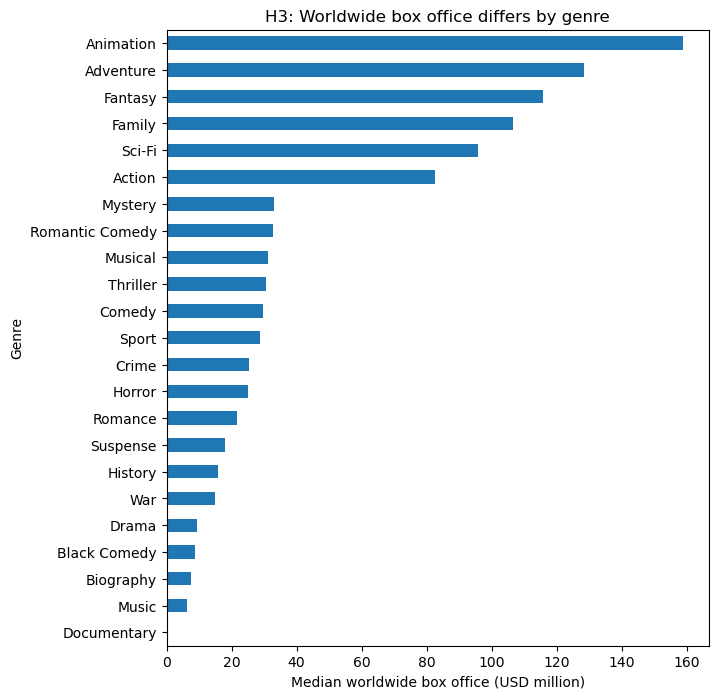

In [7]:
# H3 chart 1: median worldwide box office for every genre (highest at the top).
chart = h3_ranking.set_index("genre")["median_worldwide_box_office"].sort_values() / 1_000_000
ax = chart.plot(kind="barh", figsize=(7, 8), title="H3: Worldwide box office differs by genre")
ax.set_xlabel("Median worldwide box office (USD million)")
ax.set_ylabel("Genre")
plt.show()

In [8]:
# second part of H3: broad vs niche genres
h3_broad_niche = db.broad_vs_niche_genres()  
h3_broad_niche

,genre,predicted,films,median_worldwide_box_office
0,Animation,broad,192,158899364.0
1,Adventure,broad,668,128364431.0
2,Fantasy,broad,360,115897512.0
3,Family,broad,357,106515310.0
4,Sci-Fi,broad,370,95902238.0
5,Action,broad,801,82497035.0
6,Drama,niche,2144,9352909.0
7,Documentary,niche,382,553797.0


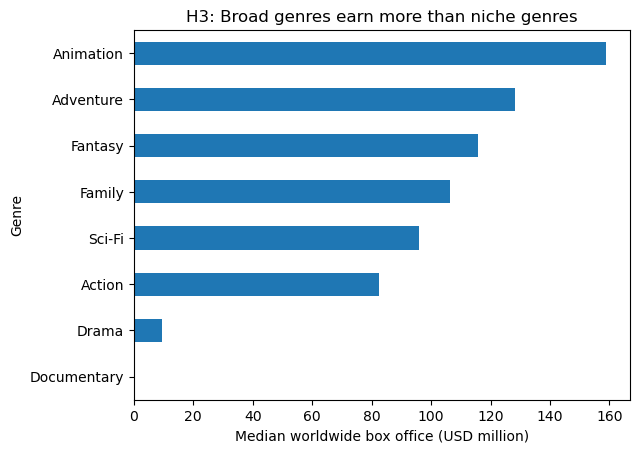

In [9]:
# H3 chart 2: the 8 genres named in H3 (highest at the top); Drama and Documentary are the niche genres.
chart = h3_broad_niche.set_index("genre")["median_worldwide_box_office"].sort_values() / 1_000_000
ax = chart.plot(kind="barh", title="H3: Broad genres earn more than niche genres")
ax.set_xlabel("Median worldwide box office (USD million)")
ax.set_ylabel("Genre")
plt.show()

## H4: Age rating
Median worldwide box office for the three rating groups H4 compares (G and PG, PG-13, R and NC-17).

In [10]:
# runs the H4 query and gives back a DataFrame
h4 = db.rating_vs_box_office()
h4

,rating_group,films,median_worldwide_box_office
0,G and PG,477,64605762.0
1,PG-13,1098,51743072.0
2,R and NC-17,1554,12370223.0


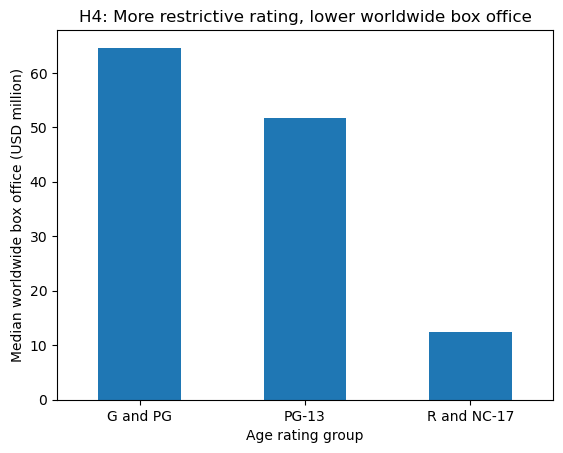

In [11]:
# H4 chart: median worldwide box office per age rating group (least to most restrictive).
chart = h4.set_index("rating_group")["median_worldwide_box_office"] / 1_000_000
ax = chart.plot(kind="bar", rot=0, title="H4: More restrictive rating, lower worldwide box office")
ax.set_xlabel("Age rating group")
ax.set_ylabel("Median worldwide box office (USD million)")
plt.show()

## H5: Review volume
Median worldwide box office for four groups of films by number of reviews (expert and user reviews together).

In [12]:
# runs the H5 query and gives back a DataFrame
h5 = db.reviews_vs_box_office()
h5

,review_volume,films,median_worldwide_box_office
0,under 25,19805,255261.0
1,25 - 49,2769,6824619.0
2,50 - 99,2065,41348628.0
3,100 and more,1588,162386776.0


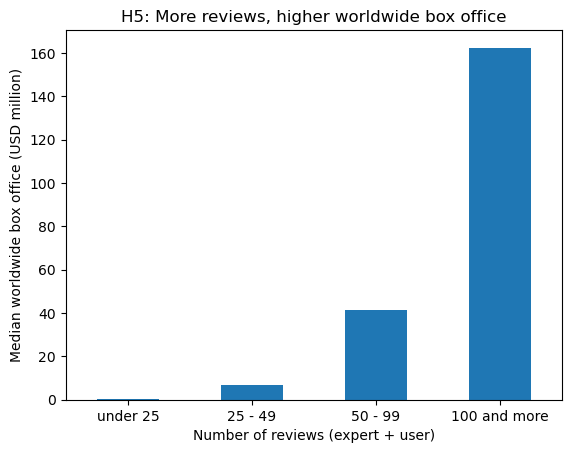

In [ ]:
# H5 chart: median worldwide box office per review-volume group (fewest reviews first).
#chart = h5.set_index("review_volume")["median_worldwide_box_office"] / 1_000_000#
# ax = chart.plot(kind="bar", rot=0, title="H5: More reviews, higher worldwide box office")
#ax.set_xlabel("Number of reviews (expert + user)")
#ax.set_ylabel("Median worldwide box office (USD million)")
#plt.show()




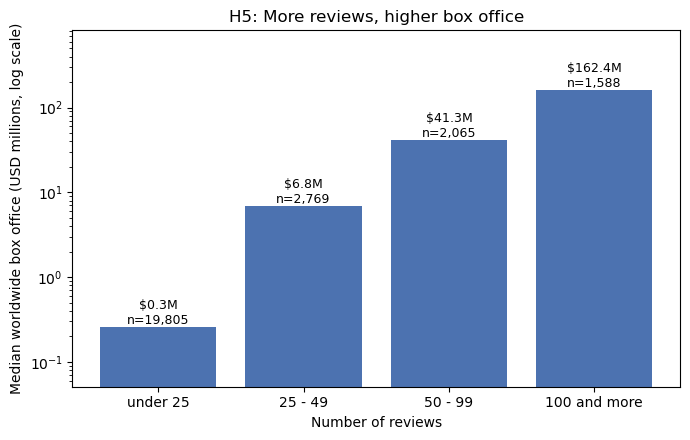

In [18]:
# H5: median worldwide box office by review volume
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(h5["review_volume"], h5["median_worldwide_box_office"] / 1e6, color="#4C72B0")
ax.set_yscale("log")   # values span ~0.25M to ~160M
ax.set_xlabel("Number of reviews")
ax.set_ylabel("Median worldwide box office (USD millions, log scale)")
ax.set_title("H5: More reviews, higher box office")
for bar, n, v in zip(bars, h5["films"], h5["median_worldwide_box_office"] / 1e6):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"${v:,.1f}M\nn={n:,}",
            ha="center", va="bottom", fontsize=9)
ax.margins(y=0.25)
plt.tight_layout()
plt.show()

## H6: Review tone
How the tone of reviews (LIWC tone, 0-100) relates to worldwide box office: first correlations, then four tone groups. Expert reviews (H6a) and user reviews from within 30 days of release (H6b) are shown separately.

In [14]:
# first part of H6: correlation between average review tone and worldwide box office
h6_correlation = db.review_tone_vs_box_office()
h6_correlation

,review_type,films,avg_tone,sd_tone,pearson_r_log,spearman_rho,t_value
0,1. expert review tone (H6a),2340,53.5,10.9,-0.018,-0.008,-0.4
1,2. user review tone (H6b),1734,62.3,19.4,0.004,-0.029,-1.2


In [15]:
# second part of H6: box office for four tone groups, per review type
h6_groups = db.review_tone_groups()
h6_groups

,review_type,tone_group,films,median_ww_musd,mean_ww_musd
0,expert review tone,1 negative (<40),242,44.0,99.6
1,expert review tone,2 neutral (40-59),1436,58.7,133.3
2,expert review tone,3 positive (60-79),649,46.6,136.0
3,expert review tone,4 very positive (80+),13,8.6,32.8
4,user review tone (±30 days),1 negative (<40),213,41.3,103.1
5,user review tone (±30 days),2 neutral (40-59),496,66.4,160.7
6,user review tone (±30 days),3 positive (60-79),724,80.3,177.3
7,user review tone (±30 days),4 very positive (80+),301,36.0,91.5


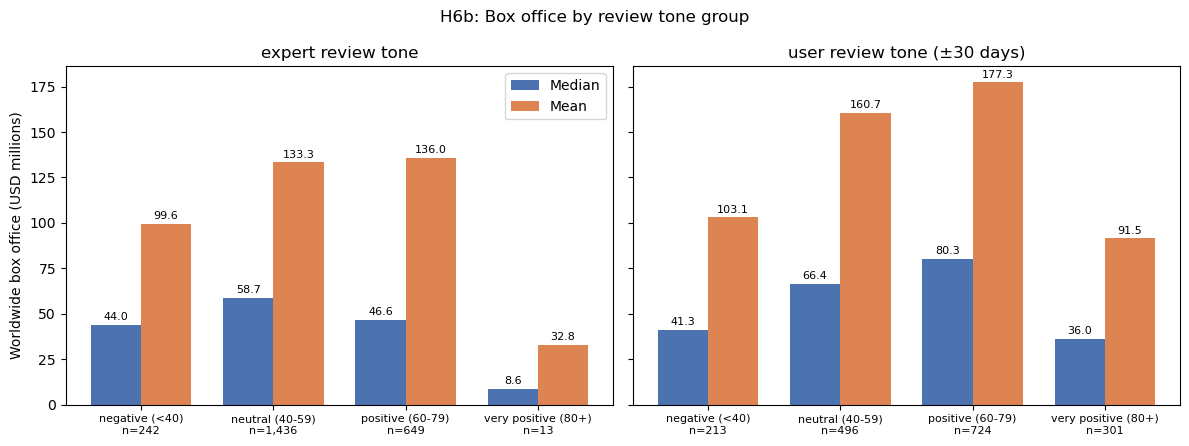

In [17]:
# H6b: median and mean box office by tone group, one panel per review type
import numpy as np

types = h6_groups["review_type"].unique()
fig, axes = plt.subplots(1, len(types), figsize=(12, 4.5), sharey=True)

for ax, rtype in zip(axes, types):
    d = h6_groups[h6_groups["review_type"] == rtype]
    x = np.arange(len(d))
    w = 0.38
    b1 = ax.bar(x - w / 2, d["median_ww_musd"], w, label="Median", color="#4C72B0")
    b2 = ax.bar(x + w / 2, d["mean_ww_musd"], w, label="Mean", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g[2:]}\nn={n:,}" for g, n in zip(d["tone_group"], d["films"])], fontsize=8)
    ax.set_title(rtype)
    ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8)
    ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8)

axes[0].set_ylabel("Worldwide box office (USD millions)")
axes[0].legend()
fig.suptitle("H6b: Box office by review tone group")
plt.tight_layout()
plt.show()